# Decision Tree - Khushi

In this notebook, we implement and analyze a Decision Tree classifier to predict whether a mushroom is edible or poisonous using the UCI Mushroom Dataset. The dataset contains categorical features describing physical characteristics of mushrooms, such as cap shape, gill color, odor, and habitat.

The objective of this analysis is to train a decision tree model and evaluate how well it can classify mushrooms based on these features. Two different splitting criteria are explored: Gini impurity and Entropy (Information Gain). These criteria determine how the tree selects features when creating decision rules.

The workflow in this notebook includes:

- Loading the Processed Dataset

- Separating the features and target variable

- Splitting the dataset into training and testing sets

- Training Decision Tree models using Gini impurity and Entropy

- Evaluating model performance using accuracy, precision, recall, and F1-score

- Visualizing model performance using a confusion matrix

- Analyzing the structure of the decision tree, including tree depth and number of leaves

- Interpreting the model by examining feature importance from the Gini-based decision tree

- Identifying the root node feature used for the first split

- Visualizing the full decision tree structure

- Investigating potential overfitting by comparing training and testing accuracy

- Analyzing how different maximum tree depths affect model performance

This analysis provides insight into how decision trees learn patterns in the mushroom dataset and which physical characteristics are most useful for distinguishing between edible and poisonous mushrooms.

In [2]:
# Load the Processed Dataset
import pandas as pd

df = pd.read_csv("../Sources/data/processed_mushrooms.csv")

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


In [3]:
# Separate Features and Target
X = df.drop("class", axis=1)
y = df["class"]

In [4]:
# Train/Test Split (80/20)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [5]:
# Train Decision Tree Classifier with Gini Impurity
from sklearn.tree import DecisionTreeClassifier

dt_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

dt_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [6]:
# Train Decision Tree Classifier with Entropy (Information Gain)
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [7]:
# Make Predictions
y_pred_gini = dt_gini.predict(X_test)
y_pred_entropy = dt_entropy.predict(X_test)

In [8]:
# Evaluate Performance using Accuracy, Precision, Recall, and F-1 Score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred):

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F-1 Score:", f1_score(y_true, y_pred))

In [9]:
# Run Evaluation for Both Gini Impurity and Entropy 
print("GINI RESULTS")
evaluate(y_test, y_pred_gini)
print()

print("ENTROPY RESULTS")
evaluate(y_test, y_pred_entropy)

GINI RESULTS
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F-1 Score: 1.0

ENTROPY RESULTS
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F-1 Score: 1.0


Both splitting criteria produce identical classification performance on this dataset, achieving perfect accuracy, precision, recall, and F-1 score.

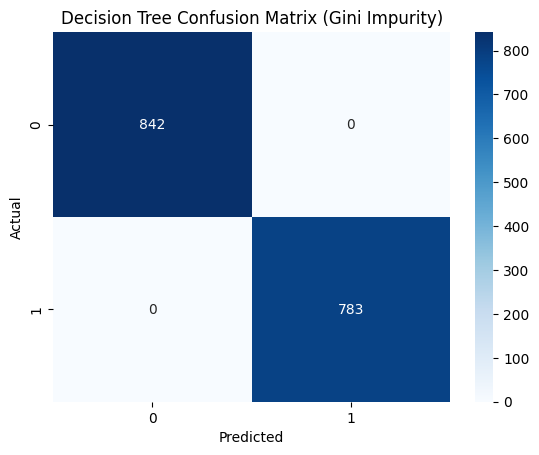

In [10]:
# Confusion Matrix using Gini Impurity 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gini)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix (Gini Impurity)")
plt.show()

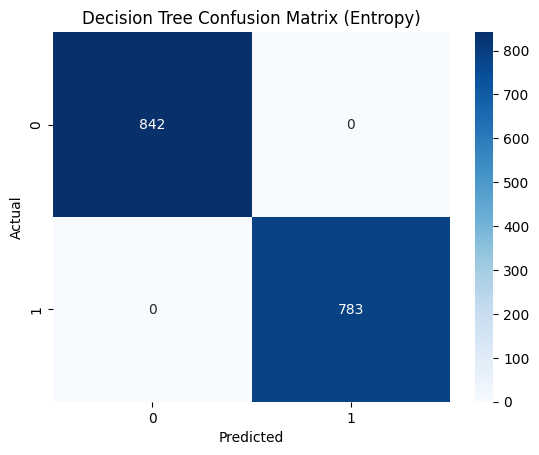

In [11]:
# Confusion Matrix using Entropy
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_entropy)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix (Entropy)")
plt.show()


The confusion matrix for the decision tree trained using entropy (information gain) shows that all edible and poisonous mushrooms were correctly classified. There are no false positives or false negatives, meaning the model achieved perfect classification on the test dataset.

The results are identical to those obtained using the Gini impurity decision tree, indicating that both splitting criteria perform equally well for this dataset. This suggests that the mushroom dataset contains strong predictive features that allow the decision tree to clearly separate edible and poisonous mushrooms regardless of the splitting criterion used.

 Because the entropy and Gini decision trees produced identical performance metrics, further interpretation of the tree structure and feature importance is conducted using the decision tree trained with Gini impurity.

In [12]:
# Analyze Tree Depth 
dt_gini.get_depth()

7

In [13]:
# Analyze number of leaves 
dt_gini.get_n_leaves()

np.int64(20)

In [14]:
# Compute Feature Importance
import pandas as pd

feature_importance = pd.Series(
    dt_gini.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

gill-color           0.338633
spore-print-color    0.191592
population           0.180495
gill-size            0.109882
stalk-root           0.067864
bruises              0.029587
habitat              0.025385
stalk-shape          0.023563
ring-number          0.017489
cap-surface          0.006147
dtype: float64

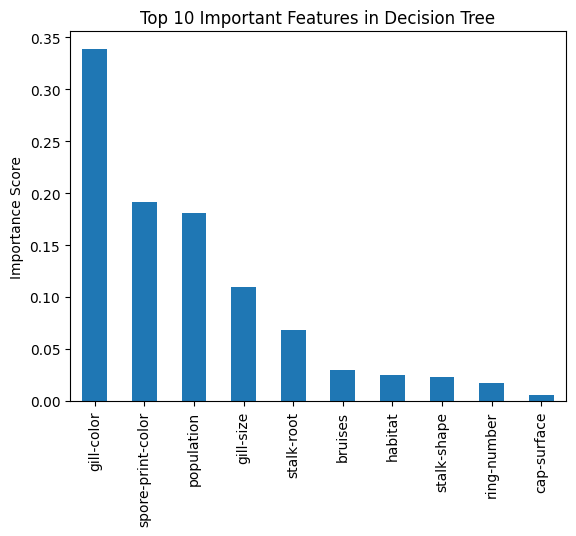

In [21]:
feature_importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features in Decision Tree")
plt.ylabel("Importance Score")
plt.show()

The decision tree model identifies several mushroom characteristics that strongly influence whether a mushroom is classified as edible or poisonous. These features represent observable physical properties of mushrooms and provide meaningful signals that help separate the two classes.

- Gill Color:
Gill color refers to the color of the gills located underneath the mushroom cap. Since gills are responsible for spore production and vary across species, their color can be strongly associated with particular mushroom types. The model indicates that certain gill colors are highly predictive of whether a mushroom is edible or poisonous.

- Spore-Print Color:
The spore-print color describes the color of the spores released by the mushroom. In mycology, spore prints are commonly used to identify mushroom species because different species produce distinct spore colors. The model identifies this feature as highly important, suggesting that spore color is a strong indicator for classification.

- Population:
Population refers to how mushrooms typically grow in an environment, such as clustered, scattered, abundant, or solitary. Different mushroom species tend to grow in distinct patterns, and some poisonous species may be more commonly found in particular population structures. This pattern helps the model distinguish between edible and poisonous mushrooms.

- Gill Size:
Gill size indicates whether the gills are broad or narrow. The structure of the gills varies across mushroom species, and certain gill sizes may appear more frequently in either edible or poisonous varieties. This structural characteristic provides additional information that supports the classification decision.

- Stalk Root:
The stalk root describes the shape or type of the mushroom’s base, such as bulbous, club-shaped, or rooted. Many mushroom identification guides rely heavily on stalk-root structure to differentiate species. Because different species have distinctive stalk bases, this feature contributes significantly to classification.

- Bruises:
This feature indicates whether the mushroom bruises or changes color when handled. Some mushrooms exhibit color changes when damaged, which can be an important characteristic for species identification. The presence or absence of bruising behavior helps the model identify patterns related to edibility.

- Habitat:
Habitat describes the environment where the mushroom is typically found, such as woods, grasses, meadows, or urban areas. Certain mushroom species are associated with specific environments, so habitat provides contextual information that helps distinguish between edible and poisonous types.

- Stalk Shape:
Stalk shape refers to whether the mushroom stalk enlarges toward the base or tapers downward. This physical structure varies across species and contributes to distinguishing different mushroom types.

- Ring Number:
Ring number indicates how many rings are present on the mushroom stalk. Rings are remnants of the mushroom’s protective veil and can differ across species. The number of rings can therefore provide useful clues for classification.

- Cap Surface:
Cap surface describes the texture of the mushroom cap, such as fibrous, scaly, or smooth. Surface texture is another visible characteristic used in mushroom identification, and certain textures may appear more frequently in specific species.

Overall, the model relies on a combination of visual, structural, and environmental features to classify mushrooms. These features collectively provide strong signals that allow the decision tree to accurately distinguish between edible and poisonous mushrooms.

In [16]:
# Find the root node of tree
root_feature_index = dt_gini.tree_.feature[0]
root_feature_name = X.columns[root_feature_index]

print("Root node feature:", root_feature_name)

Root node feature: gill-color


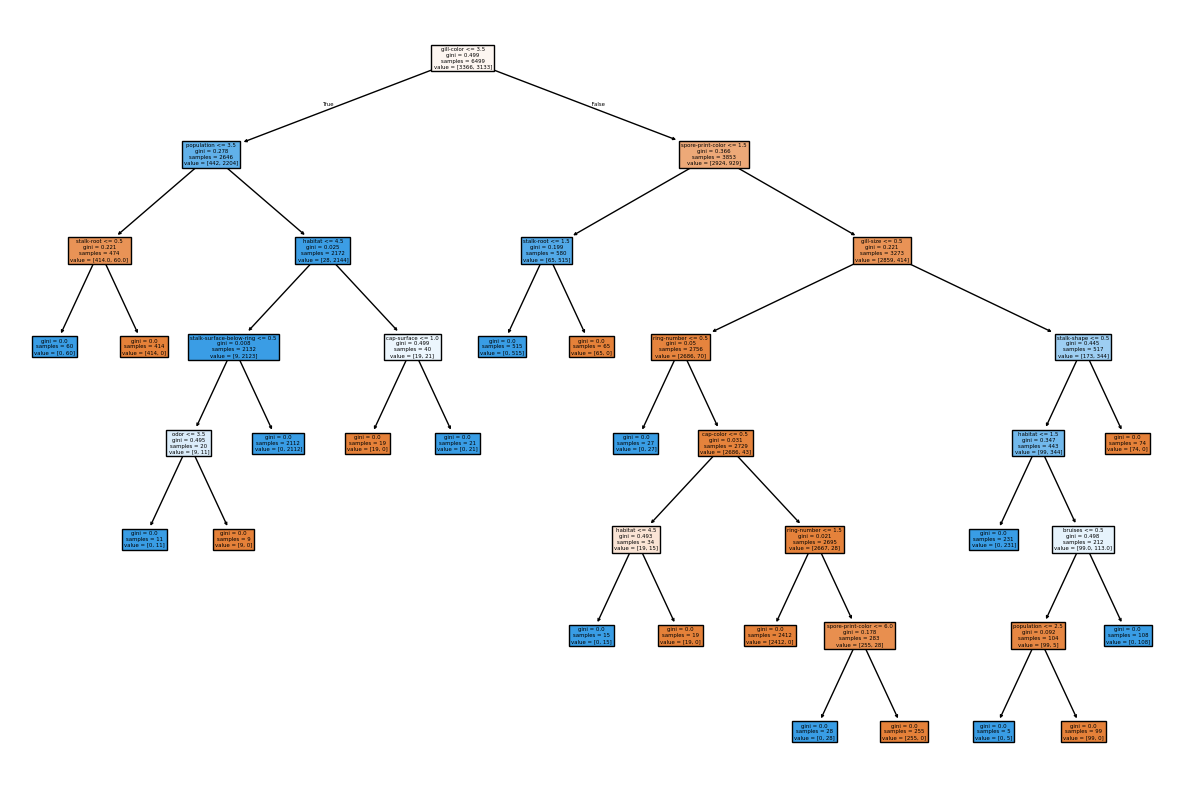

In [20]:
# Plot the Decision Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(dt_gini, feature_names=X.columns, filled=True)
plt.show()

In [ ]:
# Check for overfitting by comparing training vs test accuracy
train_acc = dt_gini.score(X_train, y_train)
test_acc = dt_gini.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 1.0
Test Accuracy: 1.0


The training and testing accuracy for the decision tree model are both equal to 1.0, meaning the model correctly classified all mushrooms in both the training and testing datasets. Overfitting typically occurs when a model performs very well on the training data but significantly worse on unseen test data. In this case, since both accuracies are identical, there is no evidence that the model is overfitting. This suggests that the dataset contains strong predictive features that allow the decision tree to generalize well.

Although the unrestricted decision tree achieved perfect accuracy, it is still useful to analyze how model complexity affects performance. Decision trees that grow very deep can sometimes overfit by creating overly specific rules. To further investigate this, additional decision trees are trained with restricted maximum depths. By comparing their training and testing accuracies, we can observe how limiting tree depth affects model performance and whether a simpler model can achieve similar results.

In [ ]:
# Analyze overfitting by training decision trees with different max_depth values and comparing their training and test accuracies

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Tree with no depth limit
dt_none = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)

dt_none.fit(X_train, y_train)

# Tree with depth = 5
dt_depth5 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_depth5.fit(X_train, y_train)

# Tree with depth = 10
dt_depth10 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    random_state=42
)

dt_depth10.fit(X_train, y_train)

print("Depth = None")
print("Train Accuracy:", dt_none.score(X_train, y_train))
print("Test Accuracy:", dt_none.score(X_test, y_test))
print()

print("Depth = 5")
print("Train Accuracy:", dt_depth5.score(X_train, y_train))
print("Test Accuracy:", dt_depth5.score(X_test, y_test))
print()

print("Depth = 10")
print("Train Accuracy:", dt_depth10.score(X_train, y_train))
print("Test Accuracy:", dt_depth10.score(X_test, y_test))



Depth = None
Train Accuracy: 1.0
Test Accuracy: 1.0

Depth = 5
Train Accuracy: 0.9781504846899522
Test Accuracy: 0.984

Depth = 10
Train Accuracy: 1.0
Test Accuracy: 1.0


The unrestricted tree (max_depth=None) and the tree with depth 10 both achieved perfect training and testing accuracy (1.0). This indicates that when the tree is allowed to grow deep enough, it can completely separate edible and poisonous mushrooms using the available features.

When the depth was restricted to 5, the training accuracy decreased slightly to 0.978, while the testing accuracy was 0.984. This small difference is likely due to random variation in the train–test split rather than model overfitting. Even with a limited depth, the model still performs extremely well, indicating that a relatively simple tree can capture most of the important patterns in the dataset.

Overall, the similar training and testing accuracies across different tree depths suggest that the decision tree does not show signs of overfitting. These results also indicate that the mushroom dataset contains strong predictive features that allow the model to accurately distinguish between edible and poisonous mushrooms.